# Clase 5 · Estimación del modelo log-normal y fórmula de Black-Scholes

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-05/clase-05-estimacion-lognormal-black-scholes.ipynb)

**Semana 5 (30/11–04/12/2026) · Temas 6 y 7 · 60 min + presentación de la Actividad 2**

Objetivos:
1. Estimar $\mu$ y $\sigma$ con tres métodos (MME, MMV, MMNP) sobre datos reales.
2. Validar el ajuste (ECM, EPAM) y predecir con intervalos de confianza al 95 %.
3. Aplicar Black-Scholes, verificar la paridad put-call y la convergencia binomial → BS.

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## Parte A · Tema 6 — Estimación, validación y predicción

### A.1 Datos (Tabla 1 del Tema 6)

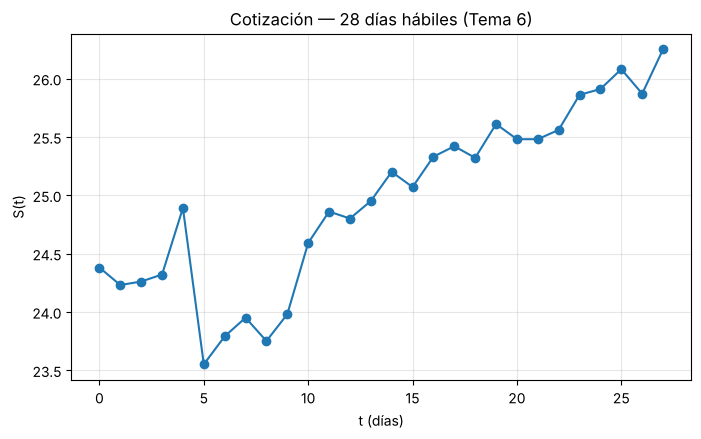

In [2]:
from mvdc import lognormal as ln

S = mvdc.datos.cargar("tema6_ibex_28dias.csv")["S"].to_numpy()
plt.plot(S, "o-"); plt.title("Cotización — 28 días hábiles (Tema 6)"); plt.xlabel("t (días)"); plt.ylabel("S(t)");

### A.2 Tres estimadores

| Método | $\hat\mu$ | $\hat\sigma$ |
|---|---|---|
| Momentos (log-retornos $U_i=\ln S_i/S_{i-1}$) | $(\bar U + s_U^2/2)/\Delta t$ | $s_U/\sqrt{\Delta t}$ |
| Máx. verosimilitud ($U_i=S_i/S_{i-1}-1$) | $\bar U/\Delta t$ | $\sqrt{\tfrac{n-1}{n\Delta t}}\,s_U$ |
| Momentos no paramétrico | $\dfrac{\sum \Delta S_i}{\Delta t\sum S_i}$ | $\sqrt{\dfrac{\sum (\Delta S_i)^2}{\Delta t\sum S_i^2}}$ |

In [3]:
tabla = ln.fit_and_validate(S, dt=1.0)
tabla.round(5)

,mu,sigma,ECM,EPAM_%
método,,,,
MME,0.00284,0.01446,0.53086,1.70139
MMV,0.00284,0.01400,0.53066,1.70012
MMNP,0.00278,0.01419,0.51789,1.61682


### A.3 Bandas de confianza al 95 % y predicción a 5 días (Figura 2 y Tabla 2)

MME                  MMV                 MMNP              
    media IC_inf IC_sup  media IC_inf IC_sup  media IC_inf IC_sup
27  26.32  22.44  30.21  26.32  22.57  30.08  26.28  22.48  30.08
28  26.40  22.44  30.36  26.40  22.56  30.24  26.35  22.47  30.24
29  26.47  22.43  30.52  26.47  22.56  30.39  26.43  22.46  30.39
30  26.55  22.42  30.68  26.55  22.55  30.55  26.50  22.46  30.55
31  26.63  22.42  30.83  26.62  22.55  30.70  26.57  22.45  30.70

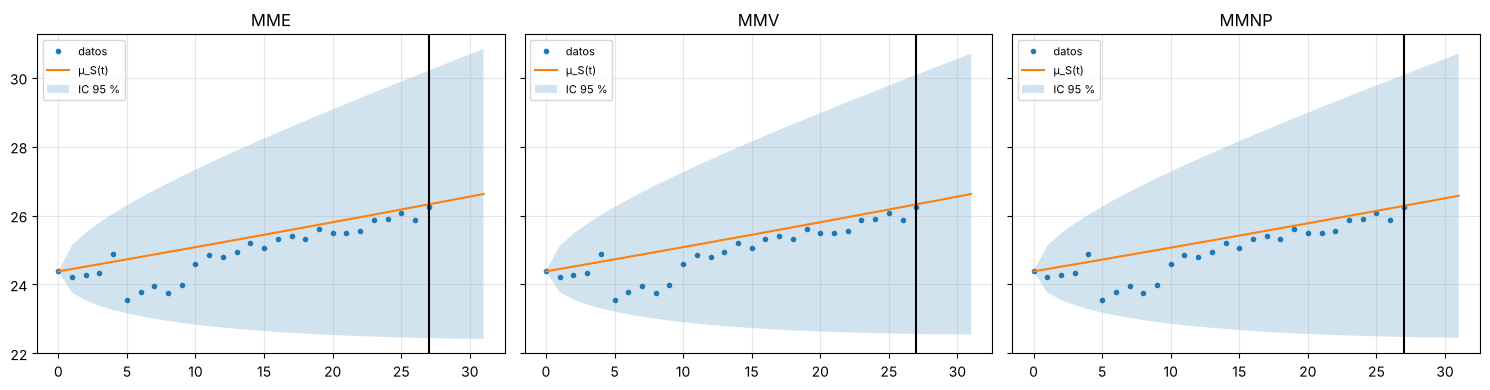

In [4]:
t_fit = np.arange(len(S)); t_pred = np.arange(len(S) - 1, len(S) + 4)
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
pred = {}
for ax, met in zip(axs, ["MME", "MMV", "MMNP"]):
    mu, sigma = tabla.loc[met, "mu"], tabla.loc[met, "sigma"]
    tt = np.arange(0, len(S) + 4)
    m, lo, hi = ln.confidence_band(S[0], mu, sigma, tt)
    ax.plot(t_fit, S, "o", ms=3, label="datos"); ax.plot(tt, m, label="μ_S(t)")
    ax.fill_between(tt, lo, hi, alpha=0.2, label="IC 95 %"); ax.axvline(len(S) - 1, color="k")
    ax.set_title(met); ax.legend(fontsize=8)
    mp, lp, hp = ln.confidence_band(S[0], mu, sigma, t_pred)
    pred[met] = pd.DataFrame({"media": mp, "IC_inf": lp, "IC_sup": hp}, index=t_pred)
plt.tight_layout()
pd.concat(pred, axis=1).round(2)

**Discusión.** ¿Por qué las bandas son tan anchas si se ajusta con $S_0$ fijo en $t=0$?
¿Qué cambiaría si re-anclamos el modelo en el último dato observado? (Pista: $\sigma_S(t)$ crece con $t$.)

## Parte B · Tema 7 — Black-Scholes

$$C = S_0N(d_1)-Ke^{-rT}N(d_2),\qquad P = Ke^{-rT}N(-d_2)-S_0N(-d_1)$$
$$d_1=\frac{\ln(S_0/K)+(r+\sigma^2/2)T}{\sigma\sqrt T},\qquad d_2=d_1-\sigma\sqrt T$$

In [5]:
from mvdc import black_scholes as bs

S0, K, T, r, sig = 74.625, 100, 1.6, 0.05, 0.375      # Ejemplos 1 y 2 del tema
d1, d2 = bs.d1_d2(S0, K, T, r, sig)
C, P = bs.bs_call(S0, K, T, r, sig), bs.bs_put(S0, K, T, r, sig)
print(f"d1={d1:.4f}  d2={d2:.4f}  C={C:.4f}  P={P:.4f}")
print("Residuo paridad put-call:", bs.put_call_parity_gap(C, P, S0, K, T, r))

d1=-0.2112  d2=-0.6856  C=8.3164  P=26.0030
Residuo paridad put-call: 3.552713678800501e-15


### B.2 Cuaderno de ejercicios del Tema 7 (los 7 casos)

In [6]:
casos = [(80, 70, 3/12, .05, .30), (60, 66, 2/12, .06, .40), (50, 60, 1, .04, .25),
         (100, 100, 4/12, .055, .50), (120, 130, 6/12, .059, .22), (40, 40, 2, .048, .60), (12, 10, 4/12, .045, .33)]
pd.DataFrame([{"S0": s, "K": k, "T": t, "r": r_, "σ": v,
               "d1": bs.d1_d2(s, k, t, r_, v)[0], "d2": bs.d1_d2(s, k, t, r_, v)[1],
               "Call": bs.bs_call(s, k, t, r_, v), "Put": bs.bs_put(s, k, t, r_, v)}
              for s, k, t, r_, v in casos]).round(4)

,S0,K,T,r,σ,d1,d2,Call,Put
0,80,70,0.2500,0.050,0.30,1.0485,0.8985,11.8450,0.9754
1,60,66,0.1667,0.060,0.40,-0.4408,-0.6041,1.9493,7.2926
2,50,60,1.0000,0.040,0.25,-0.4443,-0.6943,2.3693,10.0166
3,100,100,0.3333,0.055,0.50,0.2078,-0.0808,12.3034,10.4868
4,120,130,0.5000,0.059,0.22,-0.2471,-0.4027,4.9206,11.1416
5,40,40,2.0000,0.048,0.60,0.5374,-0.3111,14.4496,10.7882
6,12,10,0.3333,0.045,0.33,1.1309,0.9404,2.3096,0.1607


### B.3 Del árbol binomial a Black-Scholes, y Monte Carlo

Monte Carlo: 10.4645 ± 0.0646


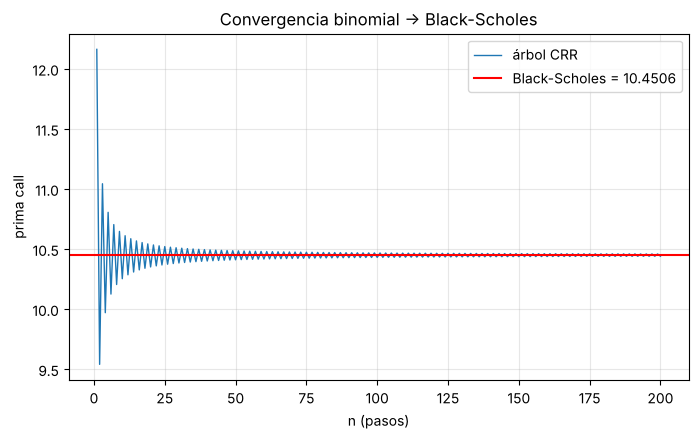

In [7]:
ns = np.arange(1, 201)
exacto = bs.bs_call(100, 100, 1, 0.05, 0.2)
plt.plot(ns, [bs.binomial_to_bs(100, 100, 1, 0.05, 0.2, n) for n in ns], lw=1, label="árbol CRR")
plt.axhline(exacto, color="r", label=f"Black-Scholes = {exacto:.4f}")
plt.xlabel("n (pasos)"); plt.ylabel("prima call"); plt.legend(); plt.title("Convergencia binomial → Black-Scholes")
mc, se = bs.mc_price(100, 100, 1, 0.05, 0.2)
print(f"Monte Carlo: {mc:.4f} ± {1.96*se:.4f}")

### B.4 Ejercicio en clase

Grafica la prima de la call y de la put en función de $\sigma \in [0.05, 0.8]$ y de $T\in[0.05, 3]$.
¿Concuerda con la Tabla 1 de sensibilidad del Tema 4? ¿Qué ocurre con la put europea al aumentar $T$?

In [8]:
# Tu código aquí

## Presentación de la Actividad 2 — Cartera de mínimo riesgo

Enunciado, rúbrica, plantilla y datos en
[`actividades/actividad-2-cartera-minimo-riesgo/`](../../actividades/actividad-2-cartera-minimo-riesgo/README.md).

**Entrega: lunes 14/12/2026, 23:59.** La teoría necesaria (Temas 8 y 9) se ve en la Clase 6;
hoy conviene empezar con la carga de datos y el cálculo de rendimientos.